# Compost 2 Analysis

This notebook focuses only on **Compost 2** and extends the earlier analysis with:

- a compact data quality profile,
- thermal delta tracking against ambient conditions,
- monthly heating demand versus retained heat,
- depth-based layer analysis,
- correlation mapping, and
- shock detection based on rolling temperature residuals.


In [2]:
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)


In [ ]:
file_path = "../data/combined_compost_measurements.csv"

df = pl.read_csv(file_path).with_columns(pl.col("Day").str.to_datetime())

# only select compost 2 values
compost_2 = df.select(
    pl.col("Day").alias("day"),
    pl.col("Compost 2-Inside-Heating - kWh").alias("heating_kwh"),
    pl.col("Compost 2-Inside-Heating - w").alias("heating_w"),
    pl.col("Compost 2-Lower-Moisture").alias("lower_moisture"),
    pl.col("Compost 2-Lower-Temperature").alias("lower_temp"),
    pl.col("Compost 2-Middle-Moisture").alias("middle_moisture"),
    pl.col("Compost 2-Middle-Temperature").alias("middle_temp"),
    pl.col("Compost 2-Upper-Moisture").alias("upper_moisture"),
    pl.col("Compost 2-Upper-Temperature").alias("upper_temp"),
    pl.col("Outside-Outside-Moisture").alias("outside_moisture"),
    pl.col("Outside-Outside-Temperature").alias("outside_temp"),
)

compost_2


day,heating_kwh,heating_w,lower_moisture,lower_temp,middle_moisture,middle_temp,upper_moisture,upper_temp,outside_moisture,outside_temp
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-05-06 00:00:00,0.0,0.0,61.8,1.5,3.4,6.4,0.0,4.3,43.7,2.8
2025-05-07 00:00:00,0.0,0.0,61.8,2.5,5.3,7.2,0.0,5.7,44.4,2.8
2025-05-08 00:00:00,0.0,0.0,62.3,4.0,5.2,8.8,0.0,7.8,46.5,4.5
2025-05-09 00:00:00,0.0,0.0,63.5,6.0,5.6,10.8,0.0,9.5,47.5,5.9
2025-05-10 00:00:00,0.0,0.0,65.9,8.8,6.7,13.2,0.0,11.9,44.2,8.0
…,…,…,…,…,…,…,…,…,…,…
2026-03-20 00:00:00,0.9,39.4,0.0,14.6,1.9,18.1,0.0,19.7,78.0,2.2
2026-03-21 00:00:00,0.9,38.9,0.0,15.3,2.3,18.7,0.0,20.1,72.5,3.8
2026-03-22 00:00:00,0.9,39.0,0.0,15.1,2.0,18.5,0.0,20.0,74.7,3.2


## Data Quality Snapshot

Before plotting trends, it helps to check whether the main Compost 2 signals are sparse, zero-heavy, or unexpectedly flat.


In [4]:
compost_2_pd = compost_2.to_pandas()
metric_cols = [column for column in compost_2_pd.columns if column != "day"]

profile = pd.DataFrame(
    {
        "missing_values": compost_2_pd[metric_cols].isna().sum(),
        "zero_share": (compost_2_pd[metric_cols] == 0).mean().round(3),
        "mean": compost_2_pd[metric_cols].mean().round(2),
        "min": compost_2_pd[metric_cols].min().round(2),
        "max": compost_2_pd[metric_cols].max().round(2),
    }
).sort_index()

profile


,missing_values,zero_share,mean,min,max
heating_kwh,0,0.548,0.47,0.0,1.2
heating_w,0,0.548,19.70,0.0,51.5
lower_moisture,0,0.582,28.13,0.0,100.0
lower_temp,0,0.000,15.21,-3.9,59.9
middle_moisture,0,0.331,4.75,0.0,47.5
middle_temp,0,0.003,17.80,0.0,60.4
outside_moisture,0,0.000,76.19,38.3,95.5
outside_temp,0,0.000,3.01,-32.2,26.8
upper_moisture,0,0.502,4.89,0.0,58.1
upper_temp,0,0.000,18.32,-0.4,49.7


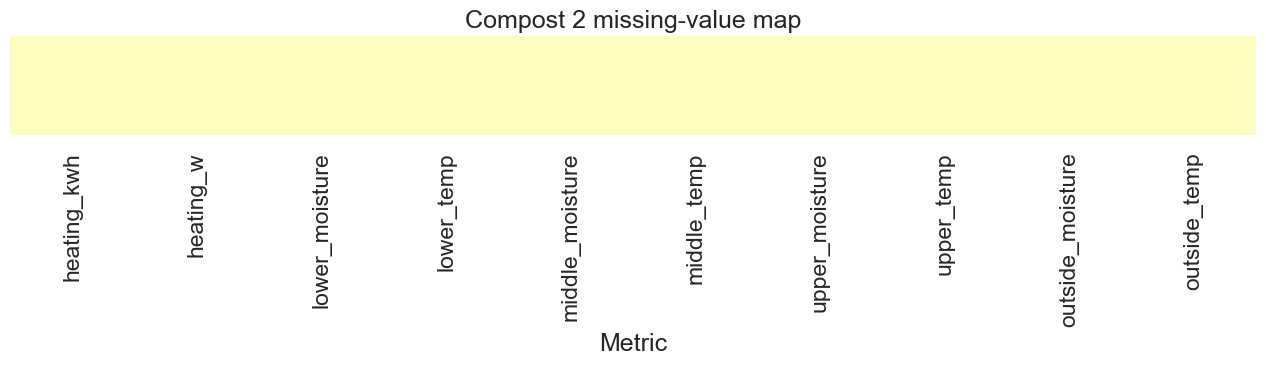

In [5]:
fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    compost_2_pd[metric_cols].isna(),
    yticklabels=False,
    cbar=False,
    cmap="magma_r",
    ax=ax,
)
ax.set_title("Compost 2 missing-value map")
ax.set_xlabel("Metric")
plt.tight_layout()
plt.show()


## Thermal Behaviour Against Ambient Temperature

The next view compares the Compost 2 core temperature with the outside air and tracks the temperature gap that the pile maintains over time.


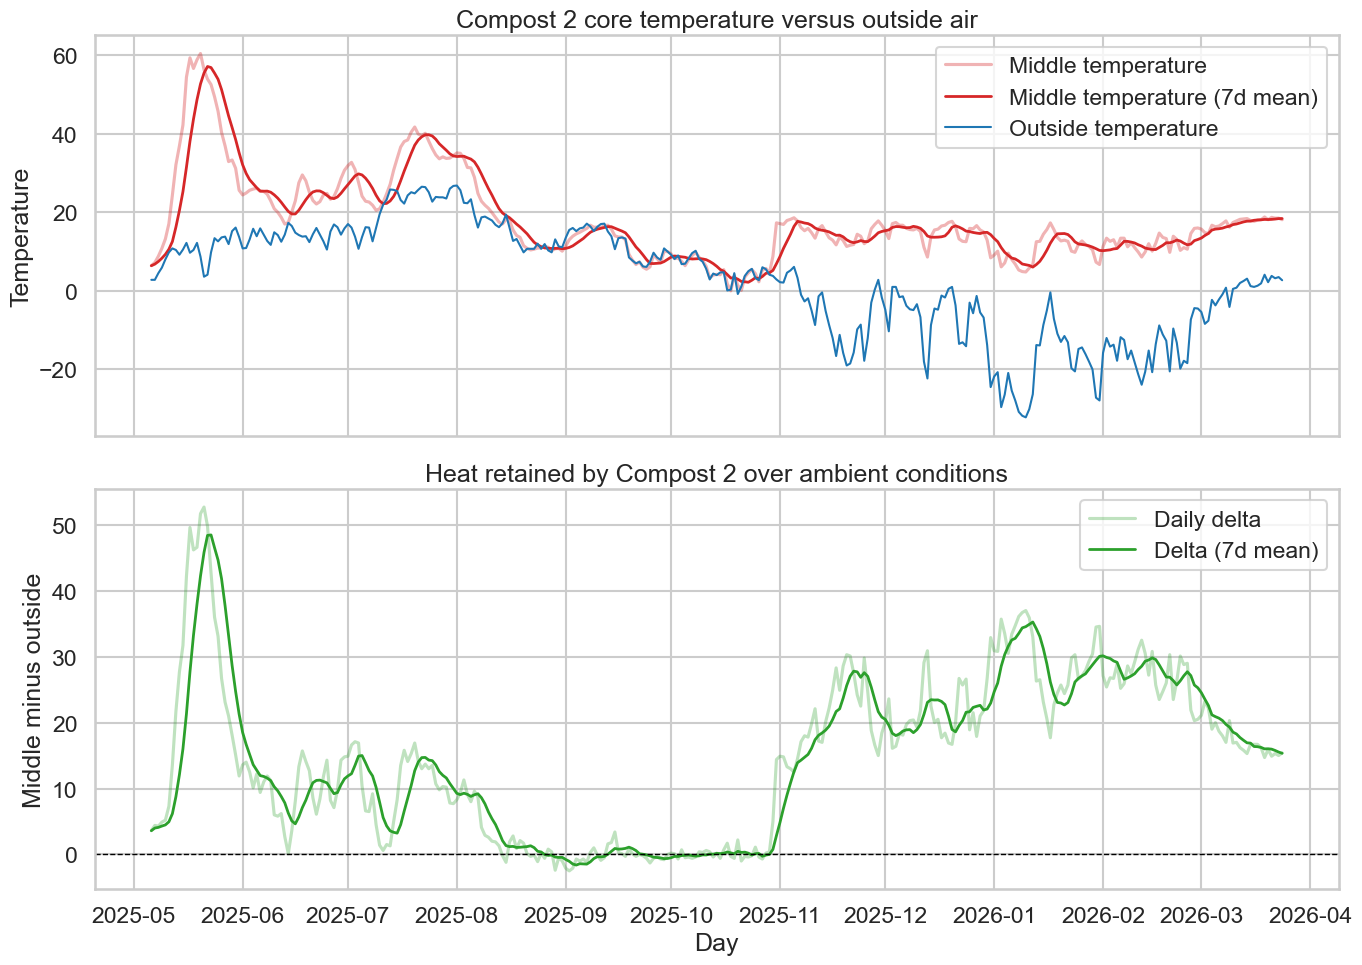

In [6]:
compost_2_pd["temp_delta"] = compost_2_pd["middle_temp"] - compost_2_pd["outside_temp"]
compost_2_pd["middle_temp_7d"] = compost_2_pd["middle_temp"].rolling(7, min_periods=1).mean()
compost_2_pd["temp_delta_7d"] = compost_2_pd["temp_delta"].rolling(7, min_periods=1).mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax1.plot(compost_2_pd["day"], compost_2_pd["middle_temp"], label="Middle temperature", color="tab:red", alpha=0.35)
ax1.plot(compost_2_pd["day"], compost_2_pd["middle_temp_7d"], label="Middle temperature (7d mean)", color="tab:red", linewidth=2)
ax1.plot(compost_2_pd["day"], compost_2_pd["outside_temp"], label="Outside temperature", color="tab:blue", linewidth=1.5)
ax1.set_ylabel("Temperature")
ax1.set_title("Compost 2 core temperature versus outside air")
ax1.legend(loc="upper right")

ax2.plot(compost_2_pd["day"], compost_2_pd["temp_delta"], color="tab:green", alpha=0.3, label="Daily delta")
ax2.plot(compost_2_pd["day"], compost_2_pd["temp_delta_7d"], color="tab:green", linewidth=2, label="Delta (7d mean)")
ax2.axhline(0, color="black", linewidth=1, linestyle="--")
ax2.set_ylabel("Middle minus outside")
ax2.set_xlabel("Day")
ax2.set_title("Heat retained by Compost 2 over ambient conditions")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


The rolling delta is useful because it separates true thermal resilience from short-lived day-to-day noise. Sustained positive gaps indicate that Compost 2 retains biologically generated or externally supported heat even during colder periods.


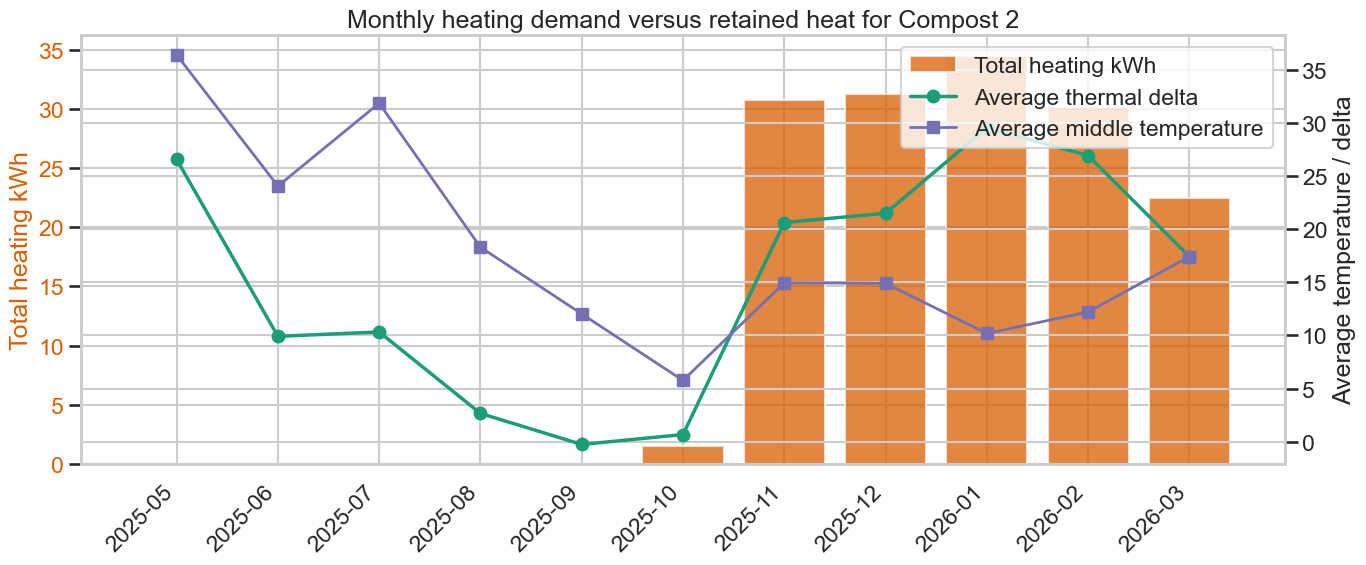

,month,avg_middle_temp,avg_outside_temp,avg_temp_delta,avg_heating_w,total_heating_kwh
0,2025-05-01,36.41,9.83,26.57,0.00,0.0
1,2025-06-01,24.06,14.14,9.92,0.00,0.0
2,2025-07-01,31.86,21.53,10.33,0.00,0.0
3,2025-08-01,18.31,15.64,2.67,0.00,0.0
4,2025-09-01,12.03,12.28,-0.25,0.00,0.0
5,2025-10-01,5.77,5.09,0.68,2.15,1.5
6,2025-11-01,14.96,-5.67,20.63,43.29,30.8
7,2025-12-01,14.91,-6.59,21.50,42.29,31.3
8,2026-01-01,10.19,-19.35,29.55,46.76,34.5
9,2026-02-01,12.21,-14.71,26.92,45.30,30.2


In [ ]:
compost_2_pd["month"] = compost_2_pd["day"].dt.to_period("M").dt.to_timestamp()

# get averages and group by month
monthly = (
    compost_2_pd.groupby("month", as_index=False)
    .agg(
        avg_middle_temp=("middle_temp", "mean"),
        avg_outside_temp=("outside_temp", "mean"),
        avg_temp_delta=("temp_delta", "mean"),
        avg_heating_w=("heating_w", "mean"),
        total_heating_kwh=("heating_kwh", "sum"),
    )
)

x = np.arange(len(monthly))

#########
# Plot Heating
######
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(x, monthly["total_heating_kwh"], color="#d95f02", alpha=0.75, label="Total heating kWh")
ax1.set_ylabel("Total heating kWh", color="#d95f02")
ax1.tick_params(axis="y", labelcolor="#d95f02")

#########
# Plot Thermal data and temperature
#########
ax2 = ax1.twinx()
ax2.plot(x, monthly["avg_temp_delta"], color="#1b9e77", marker="o", linewidth=2.5, label="Average thermal delta")
ax2.plot(x, monthly["avg_middle_temp"], color="#7570b3", marker="s", linewidth=2, label="Average middle temperature")
ax2.set_ylabel("Average temperature / delta")
ax2.tick_params(axis="y")

ax1.set_xticks(x)
ax1.set_xticklabels(monthly["month"].dt.strftime("%Y-%m"), rotation=45, ha="right")
ax1.set_title("Monthly heating demand versus retained heat for Compost 2")

handles_1, labels_1 = ax1.get_legend_handles_labels()
handles_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(handles_1 + handles_2, labels_1 + labels_2, loc="upper right")

plt.tight_layout()
plt.show()

monthly.round(2)


## Layer Behaviour Inside Compost 2

Compost systems often stratify. Looking at upper, middle, and lower layers separately helps show whether the pile is stable throughout or only active in one zone.


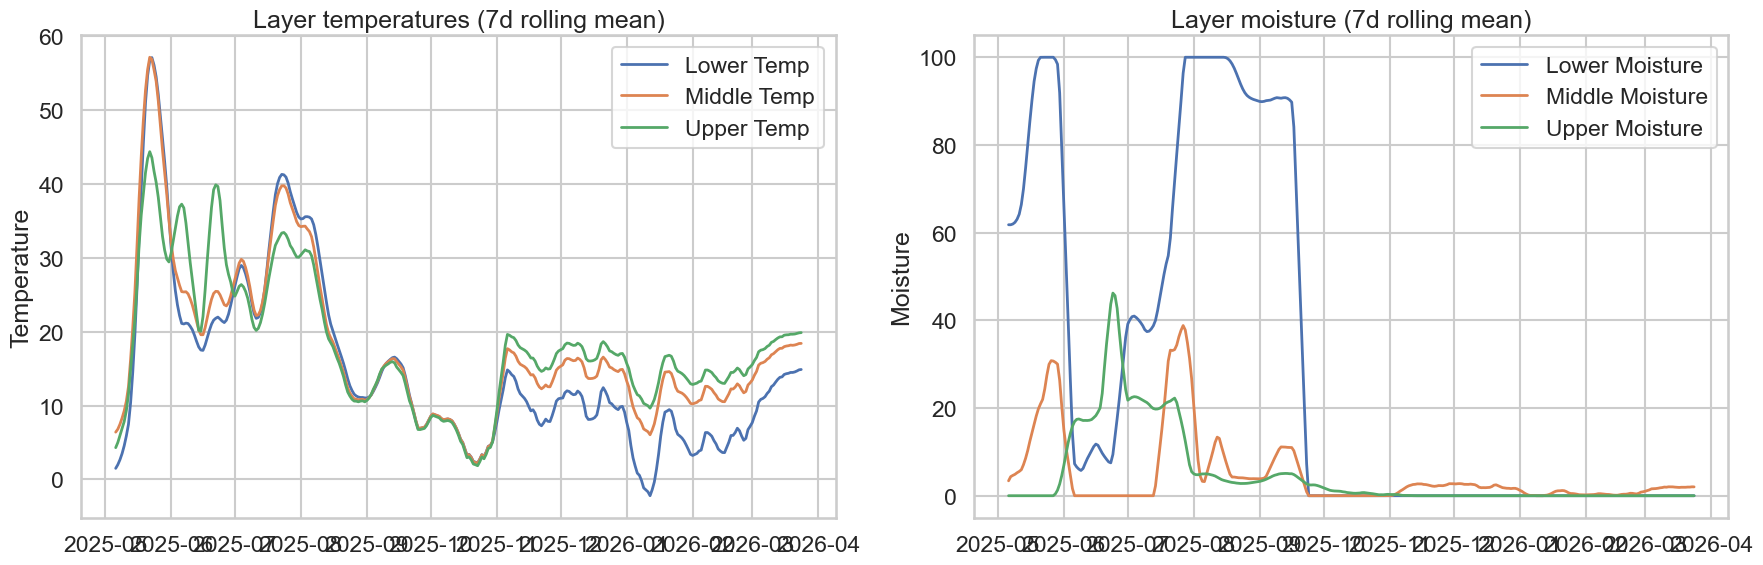

In [ ]:
# set temperature and moisture columns
layer_temp_cols = ["lower_temp", "middle_temp", "upper_temp"]
layer_moisture_cols = ["lower_moisture", "middle_moisture", "upper_moisture"]

layered = compost_2_pd[["day"] + layer_temp_cols + layer_moisture_cols].copy()
for column in layer_temp_cols + layer_moisture_cols:
    layered[f"{column}_7d"] = layered[column].rolling(7, min_periods=1).mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharex=True)

# plot a plot for each moisture and temperature columns(lower, middle, upper)
for column in layer_temp_cols:
    ax1.plot(layered["day"], layered[f"{column}_7d"], linewidth=2, label=column.replace("_", " ").title())
ax1.set_title("Layer temperatures (7d rolling mean)")
ax1.set_ylabel("Temperature")
ax1.legend(loc="upper right")

for column in layer_moisture_cols:
    ax2.plot(layered["day"], layered[f"{column}_7d"], linewidth=2, label=column.replace("_", " ").title())
ax2.set_title("Layer moisture (7d rolling mean)")
ax2.set_ylabel("Moisture")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


In [ ]:
# create a brief summary
layer_summary = pd.DataFrame(
    {
        "avg_temp": compost_2_pd[layer_temp_cols].mean().round(2),
        "temp_std": compost_2_pd[layer_temp_cols].std().round(2),
        "avg_moisture": compost_2_pd[layer_moisture_cols].mean().round(2).values,
        "moisture_std": compost_2_pd[layer_moisture_cols].std().round(2).values,
    },
    index=["Lower layer", "Middle layer", "Upper layer"],
)

layer_summary


,avg_temp,temp_std,avg_moisture,moisture_std
Lower layer,NaN,NaN,28.13,40.20
Middle layer,NaN,NaN,4.75,9.05
Upper layer,NaN,NaN,4.89,9.44


## Cross-Metric Correlation

Correlations show which metrics move together. This is especially helpful for spotting whether heating, moisture, and temperature respond as one system or as loosely connected subsystems.


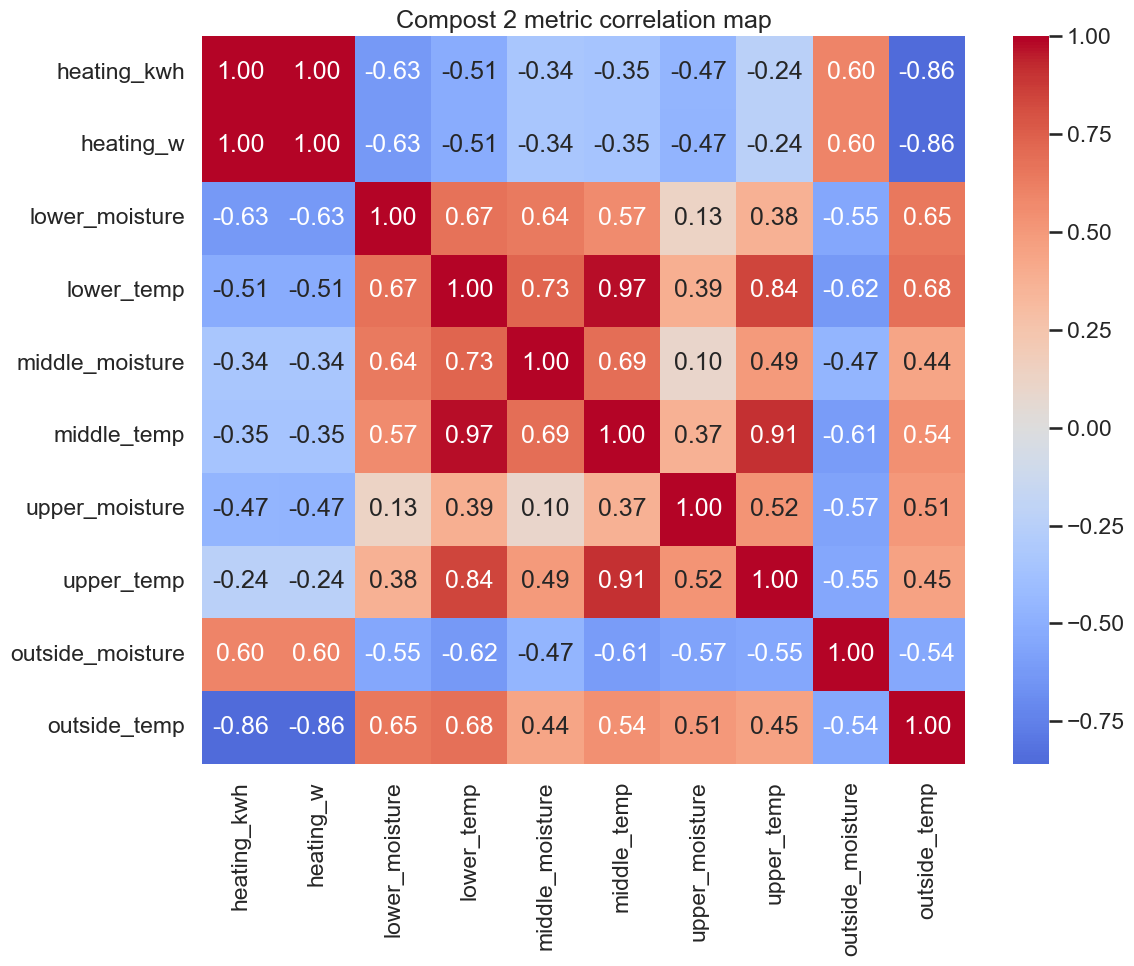

In [ ]:
# create a correlation matrix
corr_matrix = compost_2_pd[metric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Compost 2 metric correlation map")
plt.tight_layout()
plt.show()


## Rolling Shock Detection

Instead of a full anomaly model, a robust first pass is to compare the current middle temperature with its rolling median. Large residuals highlight abrupt operational changes worth investigating.


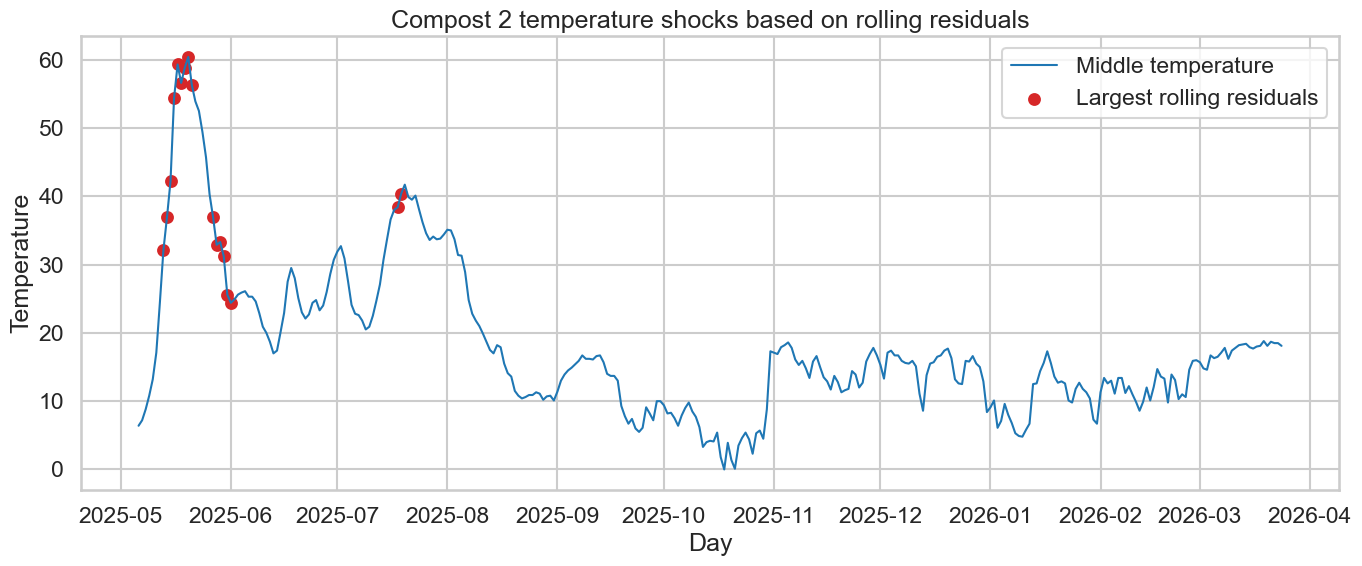

,day,middle_temp,middle_residual_14d,heating_w,outside_temp
7,2025-05-13,32.1,20.10,0.0,10.4
8,2025-05-14,36.9,23.70,0.0,9.2
9,2025-05-15,42.2,27.05,0.0,10.5
10,2025-05-16,54.4,37.30,0.0,12.2
11,2025-05-17,59.3,38.55,0.0,9.7
12,2025-05-18,56.6,32.20,0.0,10.4
13,2025-05-19,58.8,30.55,0.0,12.2
14,2025-05-20,60.4,25.90,0.0,8.7
15,2025-05-21,56.3,16.75,0.0,3.6
21,2025-05-27,36.9,-16.30,0.0,13.8


In [ ]:
# get the rolling residual of middle temp
compost_2_pd["middle_residual_14d"] = (
    compost_2_pd["middle_temp"] - compost_2_pd["middle_temp"].rolling(14, min_periods=3).median()
)

# get the scaled threshold
threshold = compost_2_pd["middle_residual_14d"].abs().quantile(0.95)

# look for "shock" events above threshold
shock_events = compost_2_pd.loc[
    compost_2_pd["middle_residual_14d"].abs() >= threshold,
    ["day", "middle_temp", "middle_residual_14d", "heating_w", "outside_temp"],
].copy()

# plot
plt.figure(figsize=(14, 6))
plt.plot(compost_2_pd["day"], compost_2_pd["middle_temp"], color="tab:blue", linewidth=1.5, label="Middle temperature")
plt.scatter(
    shock_events["day"],
    shock_events["middle_temp"],
    color="tab:red",
    s=60,
    label="Largest rolling residuals",
)
plt.title("Compost 2 temperature shocks based on rolling residuals")
plt.xlabel("Day")
plt.ylabel("Temperature")
plt.legend()
plt.tight_layout()
plt.show()

shock_events.sort_values("day")


## Takeaways

- Compost 2 can be reviewed independently now, without mixing sensor behaviour into the same narrative.
- The thermal delta and monthly demand views make it easier to judge when heating support is carrying the pile and when the pile is retaining heat on its own.
- Layer plots show whether instability is localized to one part of the pile or shared across the full compost profile.
- Rolling residuals highlight abrupt events that deserve a manual check in the raw logs or hardware notes.
